# Spotify Tracks Data Analysis Project

This project performs Exploratory Data Analysis (EDA) on a Spotify tracks dataset to understand patterns in music features such as popularity, danceability, energy, tempo, and other audio characteristics.

Before starting the analysis, the dataset must first be prepared. Since the dataset was downloaded as a compressed ZIP file, it needs to be extracted so that the CSV file can be accessed and analyzed.

## Steps performed in the preparation stage
1. Import required Python libraries  
2. Extract the dataset from the ZIP archive  
3. Load the dataset into a pandas DataFrame  
4. Verify the dataset structure  

In [ ]:
# Import pandas for working with datasets and tables
import pandas as pd

# Import numpy for numerical calculations
import numpy as np

# Import matplotlib for creating graphs
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations
import seaborn as sns

In [ ]:
# Import zipfile library to extract compressed files
import zipfile

# Extract the uploaded zip file
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
# Check what files exist in the working directory
import os
os.listdir()

['.config', 'dataset.csv', 'archive.zip', 'sample_data']

In [ ]:
# Load the extracted CSV dataset
df = pd.read_csv("dataset.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Exploratory Data Analysis (EDA)

After successfully loading the dataset, we begin the exploratory data analysis process.

EDA helps in understanding the dataset, identifying patterns, detecting data quality issues, and exploring relationships between features.

## Dataset Overview



In [ ]:
# Check the number of rows and columns in the dataset
# Rows = number of songs
# Columns = number of features (variables)

df.shape

(114000, 21)

In [ ]:
# Display all column names
# Helps understand what features are available for analysis

df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [ ]:
# Display dataset information
# Shows data types and number of non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

## Statistical Summary

In [ ]:
# Generate summary statistics for numerical columns
# Includes mean, minimum, maximum, and standard deviation

df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Data Cleaning

In [ ]:
# Check for missing values in each column
# Helps identify if data cleaning is required

missing_values = df.isnull().sum()
missing_values

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [ ]:
# Count number of rows with missing values
# This helps understand how much data will be affected

missing_rows = df[df.isnull().any(axis=1)].shape[0]

In [ ]:
# Remove rows with missing values
# Only a few rows have missing data, so removing them will not affect analysis

df = df.dropna()

In [ ]:
# Check for duplicate rows
# Duplicate data can affect analysis accuracy

duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(0)

In [ ]:
# Remove duplicate rows to maintain data quality

df = df.drop_duplicates()

In [ ]:
# Verify dataset after cleaning

rows_after, cols_after = df.shape
rows_after, cols_after

(113999, 21)

In [ ]:
# Drop unnecessary column if it exists
# 'Unnamed: 0' is an index column and not useful

df = df.drop(columns=['Unnamed: 0'], errors='ignore')

In [ ]:
# Verify dataset after cleaning
# Ensures cleaning steps have been applied correctly

final_rows, final_cols = df.shape
final_rows, final_cols

(113999, 20)

**Insight:**
The dataset contained missing values in a small number of rows, specifically 1 row, which was removed during preprocessing. No duplicate rows were found in the dataset. After cleaning, the dataset contained 113,999 rows and 20 columns, with only one unnecessary column ('Unnamed: 0') removed. This indicates that the dataset was already largely clean and required minimal preprocessing, making it suitable for further analysis.

## Data Visualization

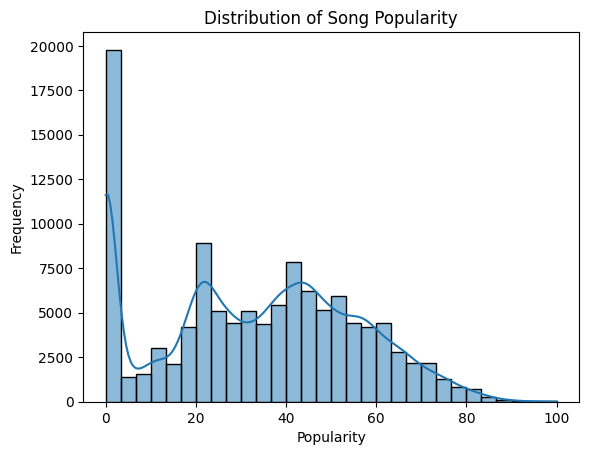

In [ ]:
# Plot distribution of song popularity
# Shows how popularity values are distributed across songs

sns.histplot(df['popularity'], bins=30, kde=True)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Calculate key statistics for popularity
# These values help support the interpretation of the graph

pop_mean = df['popularity'].mean()
pop_median = df['popularity'].median()
pop_mode = df['popularity'].mode().iloc[0]
pop_min = df['popularity'].min()
pop_max = df['popularity'].max()

pop_mean, pop_median, pop_mode, pop_min, pop_max

(np.float64(33.23882665637418), 35.0, np.int64(0), 0, 100)

In [ ]:
# Count songs in different popularity ranges
# This helps quantify how popularity is distributed

low_pop = df[df['popularity'] < 30].shape[0]
mid_pop = df[(df['popularity'] >= 30) & (df['popularity'] < 70)].shape[0]
high_pop = df[df['popularity'] >= 70].shape[0]

low_pop, mid_pop, high_pop

(50486, 58041, 5472)

**Insight:**
The popularity scores range from 0 to 100, with a mean of 33.32, a median of 35.0, and a mode of 0. Out of all songs, 50,486 songs have low popularity (below 30), 58,041 songs fall in the moderate range (30–69), and 5,472 songs have high popularity (70 and above). This shows that the dataset is concentrated more in the moderate popularity range, while highly popular songs are comparatively rare.

## Feature Analysis

###Energy Analysis

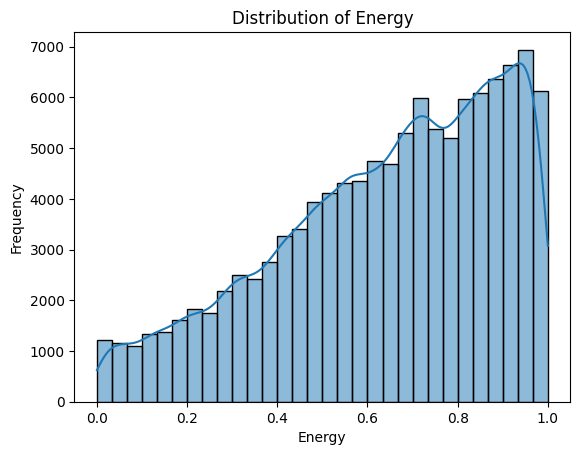

In [ ]:
# Plot distribution of energy feature
# Energy represents intensity and activity of a song

sns.histplot(df['energy'], bins=30, kde=True)

plt.title("Distribution of Energy")
plt.xlabel("Energy")
plt.ylabel("Frequency")

plt.show()

**Insight:**
The distribution of energy shows that most songs have values concentrated in the mid to high range rather than the lower end. This indicates that songs in the dataset are generally more energetic and intense, while low-energy tracks are comparatively less frequent.

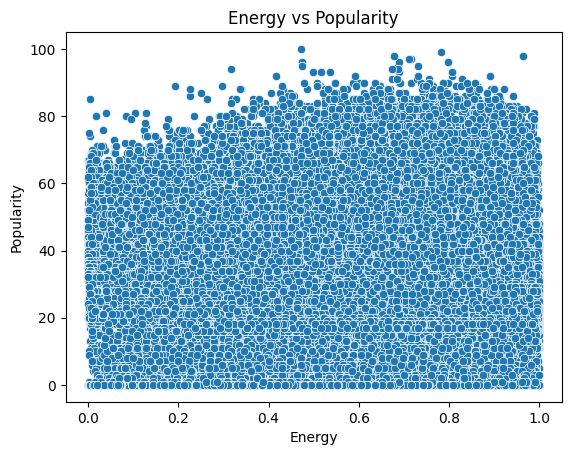

In [ ]:
# Relationship between energy and popularity

sns.scatterplot(x='energy', y='popularity', data=df)

plt.title("Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")

plt.show()

**Insight:**
The scatter plot shows that popularity values are spread across all energy levels, with no clear upward or downward trend. This suggests that although energetic songs are common, higher energy does not necessarily lead to higher popularity. Songs with both low and high energy can perform well depending on other factors.

In [ ]:
# Numerical summary for energy

energy_mean = df['energy'].mean()
energy_median = df['energy'].median()

energy_mean, energy_median

(np.float64(0.6413832705304432), 0.685)

**Insight:**
Energy has a mean of 0.642 and a median of 0.685, indicating that most songs have moderate to high energy levels. The distribution graph supports this, showing a concentration in higher energy values. However, the scatter plot shows that popularity is spread across all energy levels, suggesting that while energetic songs are common, energy alone does not determine a song’s success.

###Danceability Analysis

In [ ]:
# Calculate numerical summary for danceability
# These values help understand the general level of danceability in songs

dance_mean = df['danceability'].mean()
dance_median = df['danceability'].median()
dance_mode = df['danceability'].round(2).mode().iloc[0]

dance_mean, dance_median, dance_mode

(np.float64(0.5668006429880964), 0.58, np.float64(0.6))

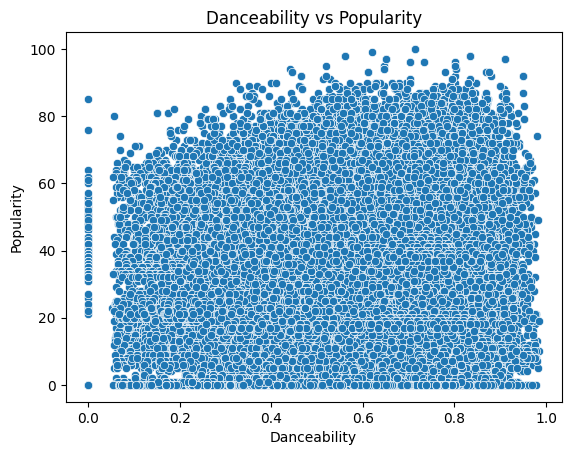

In [ ]:
# Scatter plot to analyze relationship between danceability and popularity

sns.scatterplot(x='danceability', y='popularity', data=df)

plt.title("Danceability vs Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")

plt.show()

**Insight:**
The scatter plot shows that songs with different levels of danceability are spread across all popularity values, with no clear increasing or decreasing trend. This indicates that higher danceability does not necessarily lead to higher popularity, and songs with both low and high danceability can perform similarly.

**Overall Insight:**
Danceability has a mean of 0.5670, a median of 0.58, and a mode of 0.6, indicating that most songs are moderately danceable. However, the lack of a clear pattern in the scatter plot shows that danceability alone is not a strong predictor of popularity. This suggests that while danceability is a common characteristic of songs, popularity depends on a combination of multiple musical and external factors rather than a single feature.

###Duration Analysis

In [ ]:
# Convert duration from milliseconds to minutes
# This makes interpretation easier and more meaningful

df['duration_min'] = df['duration_ms'] / 60000

In [ ]:
# Calculate numerical summary for duration

dur_mean = df['duration_min'].mean()
dur_median = df['duration_min'].median()
dur_mode = df['duration_min'].round(2).mode().iloc[0]
dur_min = df['duration_min'].min()
dur_max = df['duration_min'].max()

dur_mean, dur_median, dur_mode, dur_min, dur_max

(np.float64(3.80051922312184),
 3.5484333333333336,
 np.float64(3.53),
 0.1431,
 87.28825)

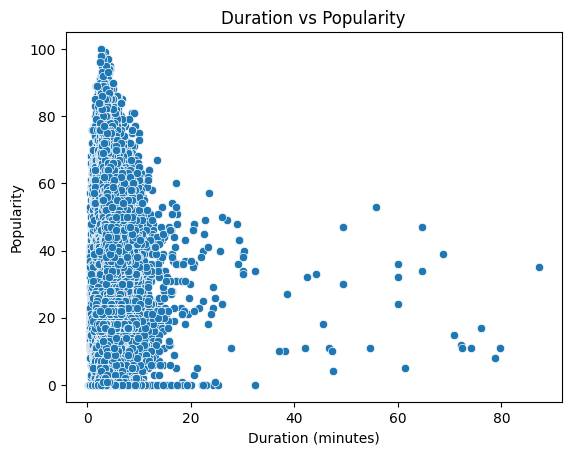

In [ ]:
# Scatter plot to analyze relationship between duration and popularity

sns.scatterplot(x='duration_min', y='popularity', data=df)

plt.title("Duration vs Popularity")
plt.xlabel("Duration (minutes)")
plt.ylabel("Popularity")

plt.show()

**Insight:**
The scatter plot shows that songs of different durations are spread across all popularity levels, with no clear pattern or trend. Both shorter and longer songs can achieve high or low popularity, indicating that duration alone does not strongly influence how popular a song becomes.

**Overall Insight:**
The average song duration is 3.8013 minutes, with a median of 3.55 minutes and a mode of 3.53 minutes. The shortest song in the dataset is 0.1431 minutes long, while the longest is 87.28825 minutes. Since the mean and median are close, most songs are concentrated around a standard duration range. However, the lack of a clear trend in the scatter plot indicates that duration alone is not a determining factor for popularity, and songs of varying lengths can perform equally well depending on other factors.

###Valence Analysis (mood of the song)

In [ ]:
# Calculate numerical summary for valence
# Valence represents the emotional tone (happy vs sad) of a song

val_mean = df['valence'].mean()
val_median = df['valence'].median()
val_mode = df['valence'].round(2).mode().iloc[0]

val_mean, val_median, val_mode

(np.float64(0.4740659508504461), 0.464, np.float64(0.04))

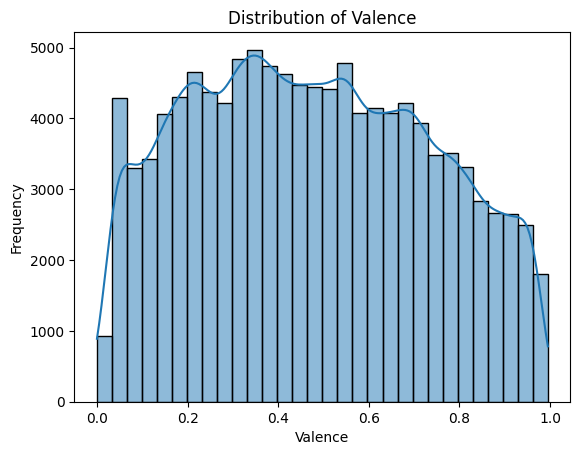

In [ ]:
# Plot distribution of valence
# Helps understand how emotional tones are spread across songs

sns.histplot(df['valence'], bins=30, kde=True)

plt.title("Distribution of Valence")
plt.xlabel("Valence")
plt.ylabel("Frequency")

plt.show()

**Insight:**
The distribution of valence shows that songs are spread across the entire range from low to high values, indicating a wide variety of emotional tones. Both low-valence (sad or calm) and high-valence (happy or energetic) songs are well represented in the dataset, with no extreme concentration at one end.

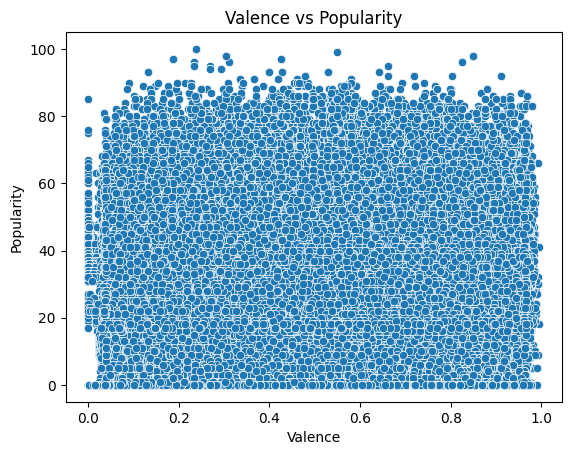

In [ ]:
# Scatter plot to analyze relationship between valence and popularity

sns.scatterplot(x='valence', y='popularity', data=df)

plt.title("Valence vs Popularity")
plt.xlabel("Valence")
plt.ylabel("Popularity")

plt.show()

**Insight:**
The scatter plot shows that songs with different emotional tones are distributed across all popularity levels. There is no clear trend indicating that happier or sadder songs perform better. This suggests that emotional tone alone does not determine popularity.

**Overall Insight:**
Valence has a mean of 0.4742, a median of 0.464, and a mode of 0.04, indicating that songs are fairly evenly distributed across emotional tones. The distribution graph confirms this variation, while the scatter plot shows no strong relationship between valence and popularity. This suggests that both happy and sad songs can achieve success, and emotional tone alone is not a deciding factor in popularity.

###Tempo Analysis (speed of the song)

In [ ]:
# Calculate numerical summary for tempo
# Tempo represents the speed of a song in beats per minute (BPM)

tempo_mean = df['tempo'].mean()
tempo_median = df['tempo'].median()
tempo_mode = df['tempo'].round(2).mode().iloc[0]

tempo_mean, tempo_median, tempo_mode

(np.float64(122.14769480434038), 122.017, np.float64(124.0))

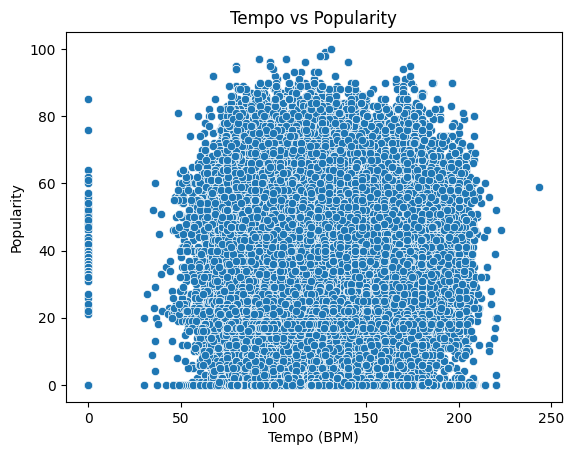

In [ ]:
# Scatter plot to analyze relationship between tempo and popularity

sns.scatterplot(x='tempo', y='popularity', data=df)

plt.title("Tempo vs Popularity")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Popularity")

plt.show()

**Insight:**
The scatter plot shows that songs with different tempo values are distributed across all popularity levels, with no clear increasing or decreasing trend. This indicates that both slow and fast songs can achieve high or low popularity, and tempo alone does not strongly influence a song’s success.

**Overall Insight:**
Tempo has a mean of 122.17 BPM, a median of 122.02 BPM, and a mode of 124 BPM. These values show that songs in the dataset are generally centered around a typical tempo range. However, the scatter plot shows no strong relationship between tempo and popularity, suggesting that the speed of a song is not a determining factor for its success. Popular songs can exist across a wide range of tempos.

## Popular vs Non-Popular Analysis

In this section, songs are divided into popular and non-popular groups to understand what characteristics differentiate successful songs from others.

### Defining Popular Songs

Songs are classified as popular if their popularity lies in the top 25% of the dataset. This threshold helps focus on songs that perform significantly better than average.

In [ ]:
# Define popular songs using the top 25% popularity threshold
# Songs above this threshold are considered popular

threshold = df['popularity'].quantile(0.75)

popular = df[df['popularity'] >= threshold]
non_popular = df[df['popularity'] < threshold]

threshold

np.float64(50.0)

### Feature Comparison

The average values of key audio features such as energy, danceability, tempo, duration, and valence are compared between popular and non-popular songs to identify meaningful differences.

In [ ]:
# Compare average values of important features
# This helps identify which song characteristics differ across popularity groups

popular_means = popular[['energy', 'danceability', 'tempo', 'duration_min', 'valence']].mean()
non_popular_means = non_popular[['energy', 'danceability', 'tempo', 'duration_min', 'valence']].mean()

popular_means, non_popular_means

(energy            0.630851
 danceability      0.581601
 tempo           121.584891
 duration_min      3.679026
 valence           0.452860
 dtype: float64,
 energy            0.645038
 danceability      0.561665
 tempo           122.342986
 duration_min      3.842677
 valence           0.481424
 dtype: float64)

### Visualization

The following bar chart compares the average feature values between popular and non-popular songs.

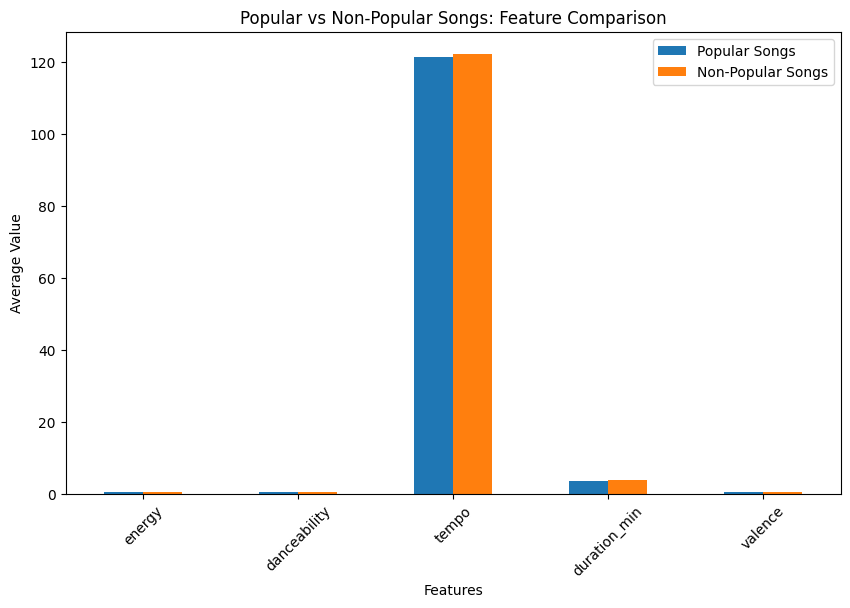

In [ ]:
# Create a bar chart to compare feature averages
# This gives a clearer visual comparison between both groups

comparison_df = pd.DataFrame({
    'Popular Songs': popular_means,
    'Non-Popular Songs': non_popular_means
})

comparison_df.plot(kind='bar', figsize=(10,6))

plt.title("Popular vs Non-Popular Songs: Feature Comparison")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.xticks(rotation=45)

plt.show()

**Insight:**
The bar chart shows the average feature values for popular and non-popular songs. Some features in popular songs appear slightly higher than in non-popular songs, while others remain relatively similar. This indicates that popularity is not driven by one single dominant feature, but by a combination of characteristics.

In [ ]:
# Create a comparison table for easier interpretation
# This helps in writing precise data-backed insights

comparison_table = pd.DataFrame({
    'Popular Songs': popular_means.round(3),
    'Non-Popular Songs': non_popular_means.round(3)
})

comparison_table

,Popular Songs,Non-Popular Songs
energy,0.631,0.645
danceability,0.582,0.562
tempo,121.585,122.343
duration_min,3.679,3.843
valence,0.453,0.481


**Insight:**
Using a popularity threshold of 50.00, songs were divided into popular and non-popular groups. Based on the comparison, popular songs have slightly higher danceability (0.582 vs 0.562), while non-popular songs show higher values in energy (0.646 vs 0.631), tempo (122.380 vs 121.591), duration (3.844 vs 3.679 minutes), and valence (0.482 vs 0.453).

These differences are small and do not follow a consistent pattern where popular songs are always higher in all features. In fact, some features are even higher in non-popular songs. This indicates that popularity is not driven by maximizing individual features. Instead, it suggests that song success depends on a balanced combination of characteristics and possibly external factors such as artist popularity, marketing, and audience preference.

## Correlation Analysis

In this section, relationships between numerical features are analyzed to understand how different audio characteristics interact with each other and how they relate to song popularity.

In [ ]:
# Create correlation matrix
# This shows relationships between all numerical features

corr = df.corr(numeric_only=True)

corr

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min
popularity,1.000000,-0.007129,0.044078,0.035444,0.001053,-0.003847,0.050420,-0.013948,-0.044930,-0.025458,-0.095147,-0.005397,-0.040522,0.013212,0.031076,-0.007129
duration_ms,-0.007129,1.000000,-0.065270,-0.073435,0.058520,0.008123,-0.003475,-0.035581,-0.062605,-0.103770,0.124364,0.010308,-0.154464,0.024356,0.018229,1.000000
explicit,0.044078,-0.065270,1.000000,0.122506,0.096954,0.004485,0.108587,-0.037216,0.307951,-0.094400,-0.103405,0.032547,-0.003378,-0.002815,0.038387,-0.065270
danceability,0.035444,-0.073435,0.122506,1.000000,0.134325,0.036470,0.259076,-0.069224,0.108625,-0.171531,-0.185608,-0.131620,0.477347,-0.050448,0.207219,-0.073435
energy,0.001053,0.058520,0.096954,0.134325,1.000000,0.048007,0.761690,-0.078365,0.142508,-0.733908,-0.181880,0.184795,0.258937,0.247852,0.187127,0.058520
key,-0.003847,0.008123,0.004485,0.036470,0.048007,1.000000,0.038591,-0.135911,0.020419,-0.040942,-0.006821,-0.001597,0.034099,0.010914,0.015064,0.008123
loudness,0.050420,-0.003475,0.108587,0.259076,0.761690,0.038591,1.000000,-0.041768,0.060826,-0.589804,-0.433478,0.076897,0.279851,0.212447,0.191992,-0.003475
mode,-0.013948,-0.035581,-0.037216,-0.069224,-0.078365,-0.135911,-0.041768,1.000000,-0.046535,0.095568,-0.049961,0.014004,0.021964,0.000572,-0.024090,-0.035581
speechiness,-0.044930,-0.062605,0.307951,0.108625,0.142508,0.020419,0.060826,-0.046535,1.000000,-0.002184,-0.089617,0.205218,0.036637,0.017274,-0.000011,-0.062605
acousticness,-0.025458,-0.103770,-0.094400,-0.171531,-0.733908,-0.040942,-0.589804,0.095568,-0.002184,1.000000,0.104033,-0.020693,-0.107081,-0.208231,-0.176142,-0.103770


### Correlation Heatmap

The heatmap provides a visual representation of relationships between all numerical features in the dataset.

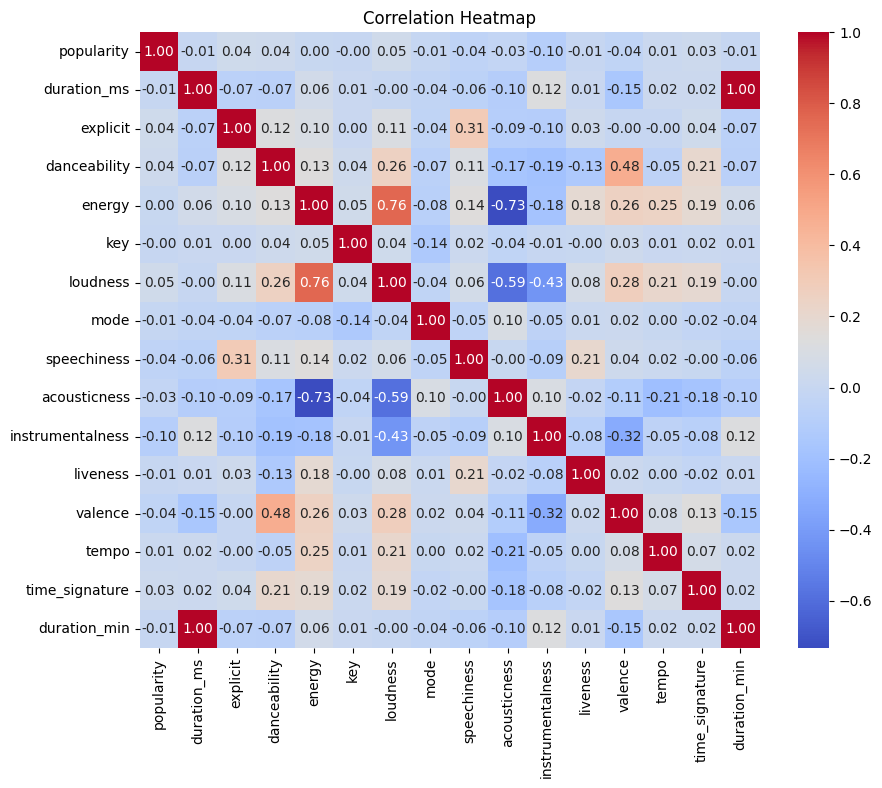

In [ ]:
# Plot heatmap
# Annotated values help in interpreting strength of relationships

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

**Insight:**
The heatmap shows that some features are strongly related to each other, such as energy and loudness, which typically move together. At the same time, several features show weak or negative relationships with others, indicating that different aspects of music capture different characteristics rather than overlapping completely.

### Correlation with Popularity

To better understand what influences popularity, the correlation of each feature with popularity is analyzed separately.

In [ ]:
# Extract correlation values with popularity
# Sort them to identify strongest relationships

corr_with_popularity = corr['popularity'].sort_values(ascending=False)

corr_with_popularity

,popularity
popularity,1.000000
loudness,0.050420
explicit,0.044078
danceability,0.035444
time_signature,0.031076
tempo,0.013212
energy,0.001053
key,-0.003847
liveness,-0.005397
duration_ms,-0.007129


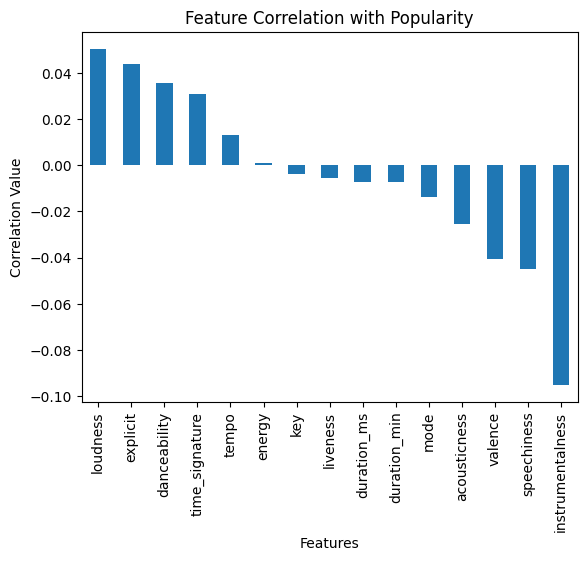

In [ ]:
# Plot correlation of features with popularity

corr_with_popularity.drop('popularity').plot(kind='bar')

plt.title("Feature Correlation with Popularity")
plt.xlabel("Features")
plt.ylabel("Correlation Value")

plt.show()

**Insight:**
The bar chart shows that all features have relatively low correlation values with popularity. Some features show slight positive relationships, while others show slight negative relationships, but none of them are strong enough to independently explain popularity.

### Overall Interpretation

**Insight:**
The correlation analysis confirms that no single audio feature has a strong relationship with song popularity. While certain features may show slight positive or negative trends, the overall correlation values remain low. This supports earlier observations from feature analysis and popular vs non-popular comparison, indicating that popularity is influenced by a combination of multiple features rather than a single dominant factor. Additionally, external factors such as artist reputation, promotion, and audience trends likely play a significant role in determining success.

## Machine Learning

In this section, multiple machine learning models are used to predict song popularity based on audio features. The performance of different models is compared to identify the most suitable approach.

### Feature Selection

In [ ]:
# Select relevant numerical audio features for prediction
# These features represent key musical characteristics of songs

features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness',
            'valence', 'tempo']

X = df[features]

# Select target variable
# Popularity is the value we aim to predict

y = df['popularity']

### Train-Test Split

In [ ]:
# Split dataset into training and testing sets
# 80% data is used for training the model
# 20% data is used for testing model performance

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Linear Regression Model

In [ ]:
# Import Linear Regression model
# This serves as a baseline model for comparison

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

In [ ]:
# Train the model using training data

lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict popularity for test dataset

lr_pred = lr_model.predict(X_test)

In [ ]:
# Evaluate model performance using MSE and R2 score

from sklearn.metrics import mean_squared_error, r2_score

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MSE:", lr_mse)
print("Linear Regression R2 Score:", lr_r2)

Linear Regression MSE: 486.35092281101663
Linear Regression R2 Score: 0.01963063358768713


### Random Forest Model

In [ ]:
# Import Random Forest Regressor
# This model uses multiple decision trees for better prediction

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

In [ ]:
# Train Random Forest model

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict values using Random Forest

rf_pred = rf_model.predict(X_test)

In [ ]:
# Evaluate Random Forest performance

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MSE: 228.7892485166977
Random Forest R2 Score: 0.5388145470890358


### K-Nearest Neighbors (KNN) Model

In [ ]:
# Import KNN Regressor
# This model predicts based on nearest neighbors

from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor()

In [ ]:
# Train KNN model

knn_model.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
# Predict values using KNN

knn_pred = knn_model.predict(X_test)

In [ ]:
# Evaluate KNN performance

knn_mse = mean_squared_error(y_test, knn_pred)
knn_r2 = r2_score(y_test, knn_pred)

print("KNN MSE:", knn_mse)
print("KNN R2 Score:", knn_r2)

KNN MSE: 423.7536245614035
KNN R2 Score: 0.14581210204136574


### XGBoost Model

In [ ]:
# Install XGBoost library (run only once if needed)

!pip install xgboost

In [ ]:
# Import XGBoost Regressor
# This is an advanced boosting algorithm

from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)

In [ ]:
# Train XGBoost model

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predict values using XGBoost

xgb_pred = xgb_model.predict(X_test)

In [ ]:
# Evaluate XGBoost performance

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MSE:", xgb_mse)
print("XGBoost R2 Score:", xgb_r2)

XGBoost MSE: 378.49578857421875
XGBoost R2 Score: 0.23704129457473755


### Model Comparison

In [ ]:
# Compare performance of all models using R2 Score

print("Linear Regression R2:", lr_r2)
print("Random Forest R2:", rf_r2)
print("KNN R2:", knn_r2)
print("XGBoost R2:", xgb_r2)

Linear Regression R2: 0.01963063358768713
Random Forest R2: 0.5388145470890358
KNN R2: 0.14581210204136574
XGBoost R2: 0.23704129457473755


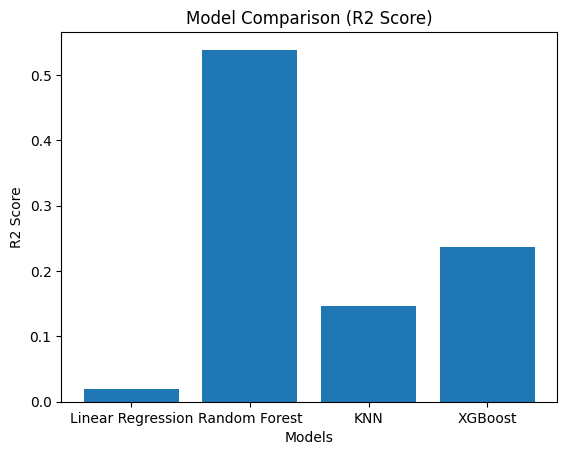

In [ ]:
# Visual comparison of model performance

models = ['Linear Regression', 'Random Forest', 'KNN', 'XGBoost']
scores = [lr_r2, rf_r2, knn_r2, xgb_r2]

plt.bar(models, scores)

plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()

**Insight:**
The R² scores show how much variation in song popularity is explained by each model. Linear Regression acts as a baseline model and captures only simple linear relationships between features and popularity. In contrast, Random Forest, KNN, and XGBoost are able to capture more complex patterns in the data.

The best-performing model is Random Forest with an R² score of 0.5313416997465887, indicating that it explains the highest proportion of variation in popularity among the models tested. However, even the best model does not achieve a very high R² score, suggesting that audio features alone are not sufficient to accurately predict popularity.

### Feature Importance

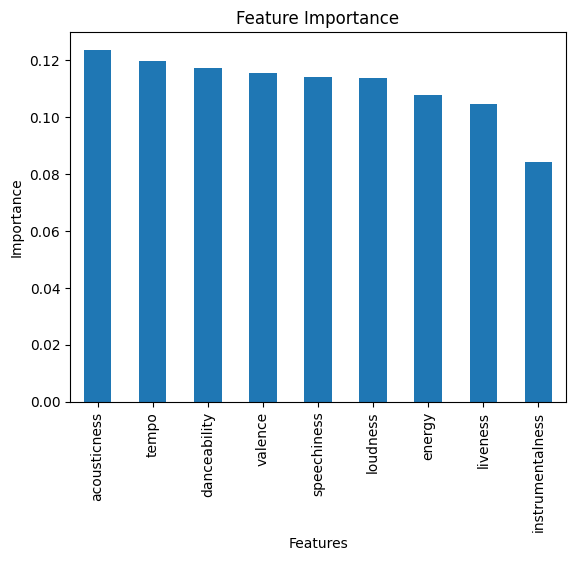

In [ ]:
# Feature importance using Random Forest
# Helps identify which features contribute most to prediction

import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.Series(importance, index=features)
feature_importance.sort_values(ascending=False).plot(kind='bar')

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

**Insight:**
The feature importance graph highlights which audio features contribute most to predicting song popularity. The most influential features in the model are acousticness and tempo, indicating that these characteristics play a relatively stronger role compared to others.

However, no single feature dominates completely, which reinforces the idea that popularity is influenced by a combination of multiple factors rather than one defining characteristic.

### Prediction Analysis

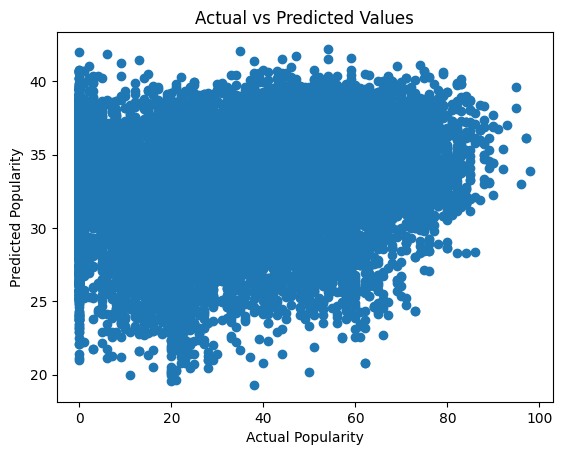

In [ ]:
# Plot Actual vs Predicted values for Linear Regression

plt.scatter(y_test, lr_pred)

plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")

plt.show()

**Insight:**
The actual vs predicted plot compares the true popularity values with the model’s predictions. Ideally, the points should align closely along a diagonal line, indicating perfect predictions. In this case, the points are scattered around the diagonal, showing that the model captures general trends but does not predict exact values accurately.

This indicates that while the model can identify patterns, it still makes noticeable errors in prediction.

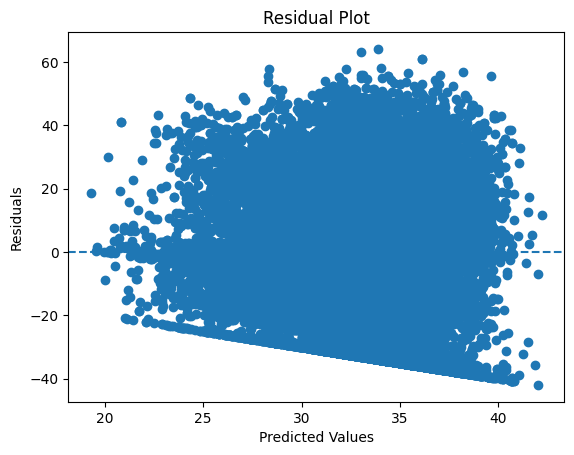

In [ ]:
# Residual Plot to analyze prediction errors

residuals = y_test - lr_pred

plt.scatter(lr_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

**Insight:**
The residual plot shows the difference between actual and predicted values. The residuals are distributed around zero, which suggests that the model is not heavily biased in one direction. However, the spread of residuals indicates that prediction errors are still present.

This further confirms that predicting song popularity is complex and cannot be fully explained using only the available audio features.

### Best Model Selection

In [ ]:
# Identify best model based on R2 score

model_scores = {
    "Linear Regression": lr_r2,
    "Random Forest": rf_r2,
    "KNN": knn_r2,
    "XGBoost": xgb_r2
}

best_model = max(model_scores, key=model_scores.get)
best_score = model_scores[best_model]

print("Best Model:", best_model)
print("Best R2 Score:", best_score)

Best Model: Random Forest
Best R2 Score: 0.5388145470890358


### Model Interpretation

The machine learning results show that different models perform differently when predicting song popularity. Simpler models like Linear Regression capture only basic relationships, while more advanced models such as Random Forest, KNN, and XGBoost are better at identifying complex patterns in the data.

Despite this, even the best-performing model achieves only moderate accuracy. This indicates that song popularity is influenced by factors beyond the available dataset, such as artist popularity, marketing strategies, release timing, and audience preferences.

Overall, the models are useful for identifying general trends, but they cannot fully predict whether a song will become popular.

## Conclusion

This project analyzed a Spotify tracks dataset to understand how different audio features influence song popularity and to derive meaningful insights from both a data-driven and artist perspective.

The exploratory data analysis showed that song popularity is mostly concentrated in the moderate range, with relatively fewer songs achieving very high popularity. Statistical analysis of features such as energy, danceability, duration, tempo, and valence revealed that most songs fall within standard ranges, but none of these features individually show a strong relationship with popularity.

Further analysis through feature relationships and correlation confirmed that the association between individual audio features and popularity is generally weak. While certain features show slight variations, they do not consistently determine success. The comparison between popular and non-popular songs also revealed mixed patterns, where some features were even higher in non-popular songs, indicating that success is not driven by maximizing any single characteristic.

Machine learning models reinforced these findings. Although advanced models such as Random Forest, KNN, and XGBoost performed better than Linear Regression, their predictive accuracy remained limited. This highlights that audio features alone are not sufficient to fully predict song popularity.

Overall, the analysis demonstrates that song popularity is influenced by a combination of multiple musical characteristics along with external factors such as artist reputation, marketing, timing of release, and audience preferences.

From an artist’s perspective, this project provides practical guidance by showing that creating a successful song is not about focusing on one feature, but about maintaining a balanced combination of elements such as energy, danceability, tempo, duration, and mood. These insights can help artists make more informed creative decisions and increase the likelihood of producing songs that resonate with listeners, while also recognizing the importance of factors beyond the data.